<a href="https://colab.research.google.com/github/k3asmitha/practise_git_github/blob/main/HAR_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Common for All


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
import os
dataset_path = "/content/drive/MyDrive/HAR_Project/dataset/UCI HAR Dataset"
os.listdir(dataset_path)

['activity_labels.txt',
 'features.txt',
 'features_info.txt',
 'README.txt',
 '.DS_Store',
 'train',
 'test']

In [14]:
#load labels
y_train = pd.read_csv(
    dataset_path + "/train/y_train.txt",
    header=None,
    delim_whitespace=True
).values.ravel()

y_test = pd.read_csv(
    dataset_path + "/test/y_test.txt",
    header=None,
    delim_whitespace=True
).values.ravel()

/tmp/ipykernel_8247/500519586.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_train = pd.read_csv(
/tmp/ipykernel_8247/500519586.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_test = pd.read_csv(


In [15]:
#Convert Labels (1–6 → 0–5)
y_train = y_train - 1
y_test = y_test - 1

#Check Labels
print("Train labels shape:", y_train.shape)
print("Test labels shape :", y_test.shape)

print("Unique labels:", np.unique(y_train))

Train labels shape: (7352,)
Test labels shape : (2947,)
Unique labels: [0 1 2 3 4 5]


common Train/Validation split for all models


In [19]:
train_idx, val_idx = train_test_split(
    np.arange(len(y_train)),
    test_size=0.2,
    random_state=42,
    stratify=y_train
)
#confirm Sizes
print("Train samples:", len(train_idx))
print("Validation samples:", len(val_idx))
print("Test samples:", len(y_test))

Train samples: 5881
Validation samples: 1471
Test samples: 2947


In [20]:
#create Split Labels
y_train_final = y_train[train_idx]
y_val = y_train[val_idx]

Till now this is Common preprocessing from this model specific changes can be done
And you should be using y_train_final
y_val
y_test

train_idx
val_idx in your models

#CNN

Inspect Inertial Signals Folder


In [22]:
train_signal_path = dataset_path + "/train/Inertial Signals"
test_signal_path  = dataset_path + "/test/Inertial Signals"

os.listdir(train_signal_path)

['body_acc_x_train.txt',
 'body_acc_y_train.txt',
 'body_acc_z_train.txt',
 'body_gyro_x_train.txt',
 'body_gyro_y_train.txt',
 'body_gyro_z_train.txt',
 'total_acc_x_train.txt',
 'total_acc_y_train.txt',
 'total_acc_z_train.txt']

In [28]:
#load All signal Files
def load_signal_file(filepath):
    data = pd.read_csv(filepath, header=None, sep='\s+')
    return data.values

train_signal_path = dataset_path + "/train/Inertial Signals/"
test_signal_path  = dataset_path + "/test/Inertial Signals/"

signal_files = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

X_train_signals = []
X_test_signals = []

for signal in signal_files:
    train_file = train_signal_path + signal + "train.txt"
    test_file  = test_signal_path  + signal + "test.txt"

    X_train_signals.append(load_signal_file(train_file))
    X_test_signals.append(load_signal_file(test_file))

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_8247/2792638324.py:3: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv(filepath, header=None, sep='\s+')


In [29]:
#stack into tensor shape
X_train_seq = np.stack(X_train_signals, axis=-1)
X_test_seq  = np.stack(X_test_signals, axis=-1)

#check shape
print("Train shape:", X_train_seq.shape)
print("Test shape :", X_test_seq.shape)

Train shape: (7352, 128, 9)
Test shape : (2947, 128, 9)


In [30]:
#Apply Common Train/Validation Split
X_train_final = X_train_seq[train_idx]
X_val = X_train_seq[val_idx]

#check Fin Shapes
print("X_train_final:", X_train_final.shape)
print("X_val        :", X_val.shape)
print("X_test_seq   :", X_test_seq.shape)

X_train_final: (5881, 128, 9)
X_val        : (1471, 128, 9)
X_test_seq   : (2947, 128, 9)


In [34]:
# Compute mean/std over samples and time axis
mean = X_train_final.mean(axis=(0,1), keepdims=True)
std  = X_train_final.std(axis=(0,1), keepdims=True)

# avoid divide by zero
std = np.where(std == 0, 1, std)

# Normalize
X_train_final = (X_train_final - mean) / std
X_val         = (X_val - mean) / std
X_test_seq    = (X_test_seq - mean) / std

#verify
print("Train mean:", X_train_final.mean())
print("Train std :", X_train_final.std())

Train mean: 5.1921683924318723e-17
Train std : 1.0000000000000036


In [36]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

#Build CNN Architecture
model = Sequential([

    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(128,9)),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
#Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#view Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       491,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 518,918 (1.98 MB)

 Trainable params: 518,918 (1.98 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
#Setup Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [40]:
#train model
history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.7978 - loss: 0.5349 - val_accuracy: 0.9531 - val_loss: 0.1545
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9398 - loss: 0.1570 - val_accuracy: 0.9585 - val_loss: 0.1138
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9463 - loss: 0.1355 - val_accuracy: 0.9653 - val_loss: 0.0958
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.9532 - loss: 0.1111 - val_accuracy: 0.9572 - val_loss: 0.0886
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9520 - loss: 0.1045 - val_accuracy: 0.9579 - val_loss: 0.0878
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9537 - loss: 0.0981 - val_accuracy: 0.9613 - val_loss: 0.0828
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.9578 - loss: 0.0927 - val_accuracy: 0.9640 - val_loss: 0.0756
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9577 - loss: 0.0887 - val_accuracy: 0.9592 - v

In [41]:
#Test Set Evaluation
test_loss, test_acc = model.evaluate(X_test_seq, y_test, verbose=0)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

#full Metrices
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
y_pred = np.argmax(model.predict(X_test_seq), axis=1)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)

Test Accuracy: 0.931795060634613
Test Loss: 0.4154927432537079
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       496
           1       0.98      0.92      0.95       471
           2       0.94      0.99      0.97       420
           3       0.88      0.78      0.83       491
           4       0.83      0.90      0.86       532
           5       1.00      1.00      1.00       537

    accuracy                           0.93      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.93      0.93      2947

[[496   0   0   0   0   0]
 [ 11 433  27   0   0   0]
 [  3   0 417   0   0   0]
 [  0   8   0 384  99   0]
 [  0   0   0  53 479   0]
 [  0   0   0   0   0 537]]


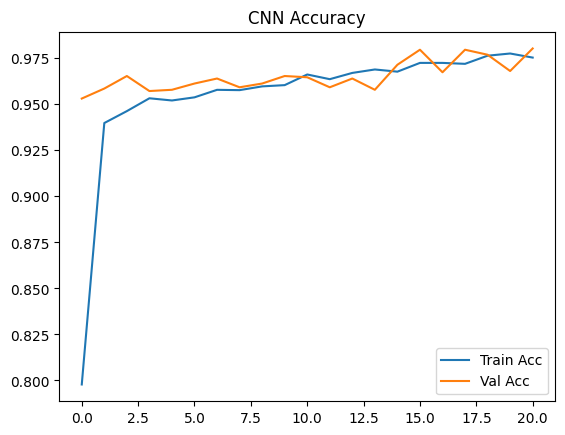

In [42]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("CNN Accuracy")
plt.show()